<a href="https://colab.research.google.com/github/JuCaRiCo/202602-AnaliticaDescriptivaPredictiva/blob/main/ProyectoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Proyecto Final

**Integrantes:**

271758 – Kevin Angel Quiñonez Dominguez

271760 – Juan Carlos Rivera Córdova

271770 – Gerardo Isidoro Reyes

---
<br/>
A continuación, se utilizarán Python y las bibliotecas de análisis de datos pertinentes para responder las siguientes preguntas de investigación:<br/><br/>

1.   ¿Se observa algún cambio estructural o quiebre de tendencia en la serie temporal después de 2017, coincidiendo con la promulgación de la Ley General en Materia de Desaparición Forzada de Personas?
2.   ¿Existe alguna relación o patrón estacional entre mes del año (ej. periodos vacacionales, o trimestres específicos) y el incremento repentino de registros?
3.   ¿Qué grupo demográfico (male o female) presentó una mayor tasa de incremento porcentual acumulado entre 2015 y 2025?
4.   ¿Cómo ha evolucionado el número de casos a través de los años?
5.   ¿Qué entidades concentran más casos y cómo se distribuyen según condición?
6.   ¿Cómo se relacionan sexo y condición, considerando las entidad?

**Montar acceso a Google Drive.**

Se incorporará acceso a Google Drive, el cual será utilizado como repositorio central para el almacenamiento y la gestión de los datos del proyecto.

Esto permitirá contar con una ubicación centralizada para la información, facilitando el acceso, la colaboración y la administración de los conjuntos de datos que serán utilizados durante el análisis.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Importacion de bibliotecas y carga de Dataset**

Se importan las bibliotecas necesarias para el análisis y se carga un archivo consolidado que integra los cuatro conjuntos de datos obtenidos. En caso de ser necesario, la información será filtrada utilizando el campo status_id, dependiendo de los requerimientos específicos de cada análisis.

Este enfoque permite trabajar sobre una fuente de datos unificada, facilitando la exploración, transformación y análisis de la información de manera consistente a lo largo del proyecto.

DataSet en Github: https://github.com/JuCaRiCo/202602-AnaliticaDescriptivaPredictiva/blob/main/all_desappiarences.csv

Colab URL: https://colab.research.google.com/drive/1mWKZ7OiW7gbOWALpuV7ZTJb-nWhZal7o?usp=sharing

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Cargamos el dataset
df = pd.read_csv('/content/drive/MyDrive/MIAAD/202602-AnaliticaDescriptivaPredictiva/Proyecto/Datos/all_desappiarences.csv')
df

,cvegeo,cve_estado,state,cve_mun,municipality,male,female,undefined,total,year,month,status_id
0,1001,1,aguascalientes,1,aguascalientes,19,21,0,40,2015,1,0
1,1001,1,aguascalientes,1,aguascalientes,7,14,0,21,2015,2,0
2,1001,1,aguascalientes,1,aguascalientes,12,23,0,35,2015,3,0
3,1001,1,aguascalientes,1,aguascalientes,17,28,0,45,2015,4,0
4,1001,1,aguascalientes,1,aguascalientes,11,24,0,35,2015,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...
139300,32999,32,zacatecas,999,se desconoce,1,0,0,1,2024,1,3
139301,99998,99,unknown,999,se desconoce,0,1,0,1,2019,9,3
139302,99998,99,unknown,999,se desconoce,1,0,0,1,2019,10,3
139303,99998,99,unknown,999,se desconoce,0,1,0,1,2019,11,3


**Se valida si existen datos duplicados.**

Se realiza un conteo de los registros cargados en el DataFrame con el objetivo de validar el volumen de información importada. Posteriormente, se verificará la existencia de registros duplicados para garantizar la calidad de los datos antes de continuar con las etapas de limpieza, transformación y procesamiento.

Esta validación inicial permite asegurar la integridad del conjunto de datos y reducir posibles inconsistencias que pudieran afectar los resultados del análisis.

In [5]:
totalRecords = len(df)
print('Total de records: ',totalRecords)

#Total de records duplicados usando 'first'
duplicatedFirst = df.duplicated(keep='first').sum()
print("Duplicados (keep='first'): ", duplicatedFirst)

Total de records:  139305
Duplicados (keep='first'):  0


**Primera Pregunta**


Para responder a la primera pregunta de investigación, “***¿Se observa algún cambio estructural o quiebre de tendencia en la serie temporal después de 2017, coincidiendo con la promulgación de la Ley General en Materia de Desaparición Forzada de Personas?***”, se comienza agrupando los datos por año y calculando los totales de las variables male, female, undefined y total.
<br/><br/>
Este análisis inicial permite obtener una visión general de la evolución de los registros a lo largo del tiempo e identificar posibles cambios en su comportamiento. Posteriormente, los resultados se representarán gráficamente con el fin de visualizar tendencias, incrementos o disminuciones significativas y evaluar la existencia de posibles quiebres estructurales a partir de 2017.
<br/><br/>
La combinación de análisis estadístico y visualización facilitará la detección de patrones temporales que puedan estar asociados con cambios normativos, administrativos o sociales ocurridos durante el periodo de estudio.

**Nota**: Se crea el DataFrame df_year

In [6]:
# Sumatoria por AÑO
df_year = (
    df.groupby('year')[['male', 'female', 'undefined', 'total']]
    .sum()
    .reset_index()
    .sort_values('year')
)

print('--- Sumatoria por Año ---')
df_year

--- Sumatoria por Año ---


,year,male,female,undefined,total
0,2015,15142,12804,14,27960
1,2016,17426,13198,22,30646
2,2017,21534,14216,48,35798
3,2018,22282,13930,118,36330
4,2019,31196,18470,404,50070
5,2020,30748,19714,46,50508
6,2021,32376,19550,14,51940
7,2022,31463,18668,54,50185
8,2023,39244,24827,60,64131
9,2024,44399,26594,38,71031


**Graficacion para responder Primera Pregunta.**

Una vez que la información ha sido filtrada y almacenada en el DataFrame df_year, se procede a la generación de las visualizaciones correspondientes.
<br/><br/>
Las gráficas permiten analizar de forma más clara la evolución de los registros a lo largo del tiempo, facilitando la identificación de tendencias, variaciones significativas y posibles cambios estructurales en la serie temporal. Asimismo, sirven como una herramienta complementaria al análisis estadístico para evaluar visualmente el comportamiento de las variables male, female, undefined y total a nivel anual.
<br/><br/>
A partir de estas representaciones gráficas, será posible realizar una evaluación preliminar sobre la existencia de cambios en la tendencia de los registros, particularmente en torno al año 2017, y determinar si se observan patrones que justifiquen análisis adicionales.

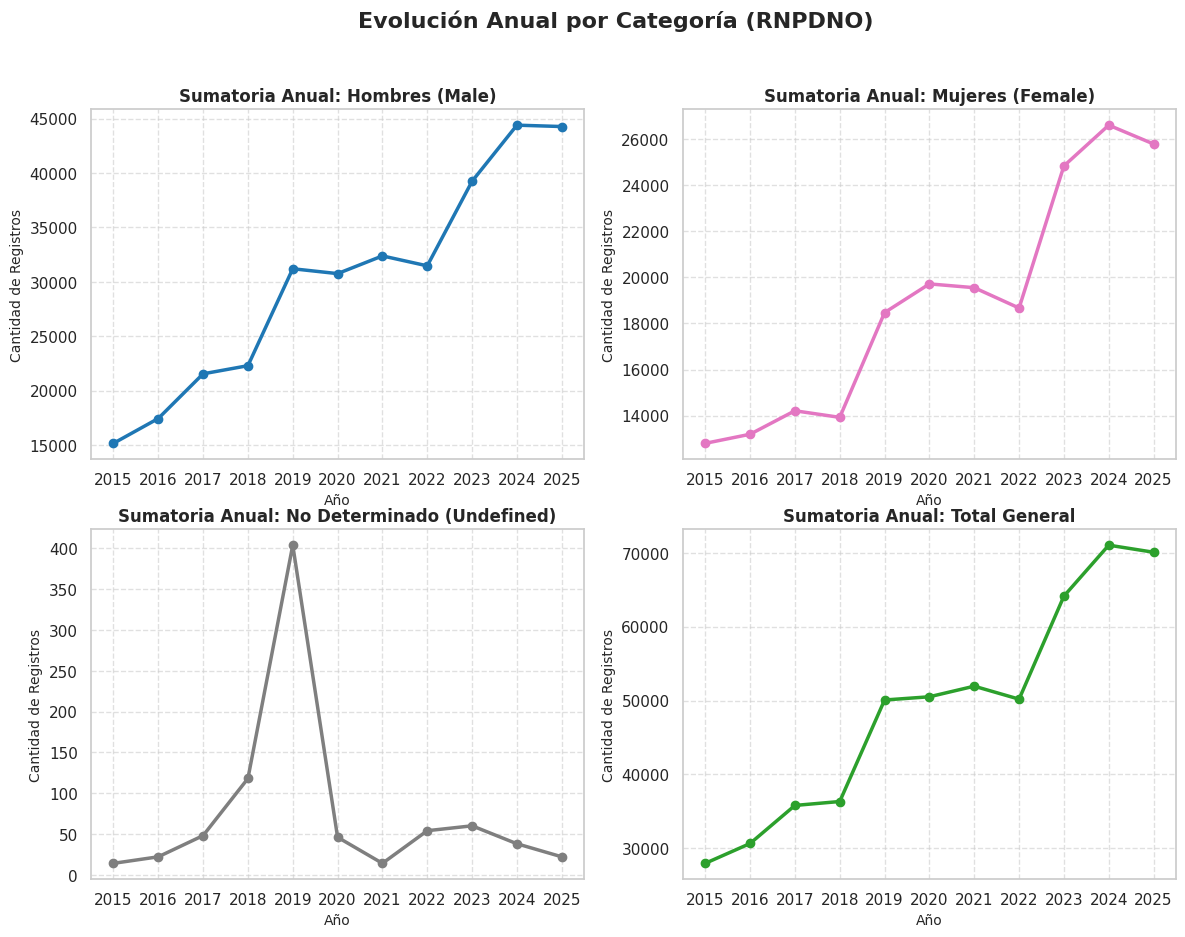

In [7]:
sns.set_theme(style='whitegrid')

# Creamos una figura de 2x2 para las 4 columnas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Evolución Anual por Categoría (RNPDNO)', fontsize=16, fontweight='bold'
)

# Configuración de cada columna
config = [
    ('male', 'Hombres (Male)', '#1f77b4'),
    ('female', 'Mujeres (Female)', '#e377c2'),
    ('undefined', 'No Determinado (Undefined)', '#7f7f7f'),
    ('total', 'Total General', '#2ca02c'),
]

for ax, (col, titulo, color) in zip(axes.flatten(), config):
  ax.plot(
      df_year['year'],
      df_year[col],
      marker='o',
      linewidth=2.5,
      color=color,
      label=titulo,
  )

  ax.set_title(f'Sumatoria Anual: {titulo}', fontsize=12, fontweight='bold')
  ax.set_xlabel('Año', fontsize=10)
  ax.set_ylabel('Cantidad de Registros', fontsize=10)
  ax.set_xticks(df_year['year'].unique())
  ax.grid(True, linestyle='--', alpha=0.6)

**Respuesta a la pregunta 1: "¿Se observa algún cambio estructural o quiebre de tendencia en la serie temporal a partir de 2017, coincidiendo con la promulgación de la Ley General en Materia de Desaparición Forzada de Personas?"**<br/>

Los resultados sugieren la existencia de un cambio en la tendencia de la serie temporal a partir de 2017. En la gráfica de registros totales se observa un incremento sostenido entre 2015 y 2017, seguido por una aceleración más marcada en los años posteriores, particularmente entre 2018 y 2019, cuando el número de registros aumenta de aproximadamente 36 mil a 50 mil casos.<br/>

Este comportamiento también se refleja en las categorías de hombres y mujeres, donde se aprecia un crecimiento más pronunciado después de 2017 en comparación con los años previos. Aunque la tendencia ya mostraba una trayectoria ascendente antes de 2017, los incrementos observados a partir de dicho año parecen indicar una posible modificación en la dinámica de registro y reporte de los casos.<br/>

La coincidencia temporal entre este cambio y la promulgación de la Ley General en Materia de Desaparición Forzada de Personas sugiere una posible relación. Sin embargo, a partir del análisis visual no es posible establecer una relación causal directa. <br/>

En conclusión, No existe evidencia visual de un posible cambio de tendencia posterior a 2017, se sugiere analizar el impacto o relación con respecto a personas encontradas después de la promulgación de la ley que tomó efecto en Enero del 2018.


Segunda Pregunta.

Para responder a la pregunta ¿Existe alguna relacion o patron estacional entre mes del año (ej. periodos vacacionales, o trimestres especificos) y el incremento repentino de registros? utilizaremos una grafica de boxplot para poder identificar variaciones y picos anomalos durante cada mes.

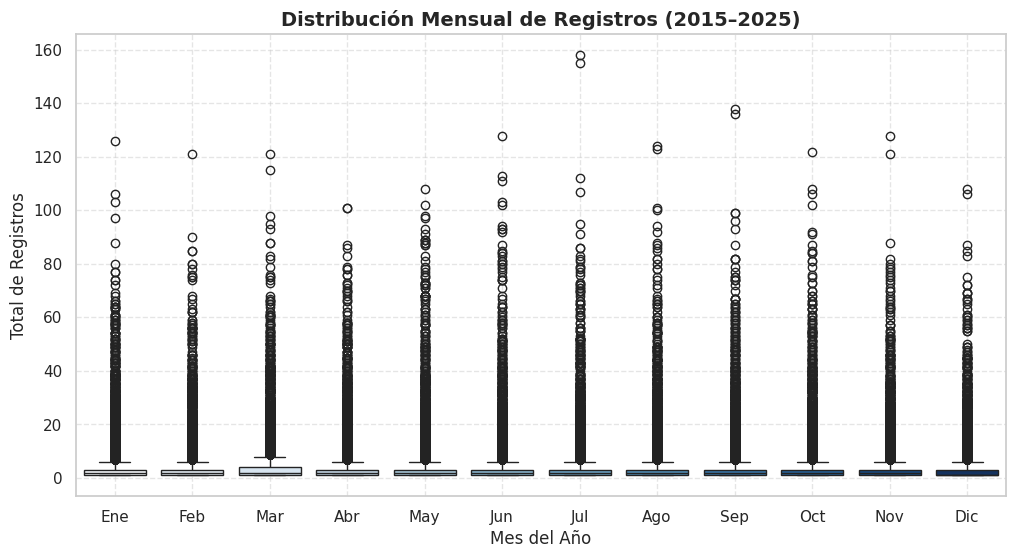

In [8]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='month', y='total', data=df, hue='month', palette='Blues', legend=False
)

plt.title(
    'Distribución Mensual de Registros (2015–2025)',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Total de Registros', fontsize=12)
plt.xticks(
    range(0, 12),
    ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic',],
)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Grafica Complementaria.
Se agrega una grafica complementaria de Mapa de Calor Año vs Mes. Nos da la oportunidad de ver la intensidad de calor representando la cantidad de registros acumulados. Nos permite detectar instantaneamente posibles patrones estacionales recurrentes, distingue con claridad si un incremento ocurrio de manera aislada en un año.

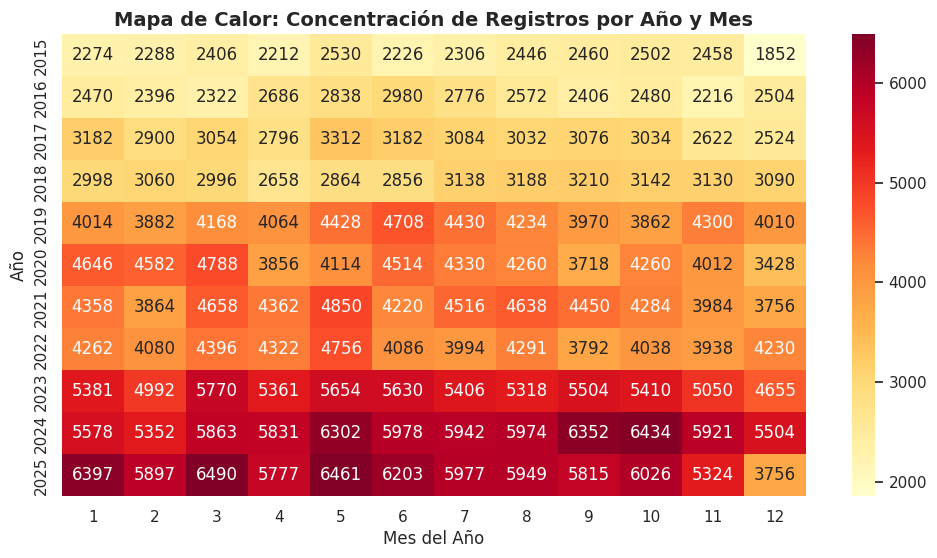

In [9]:
# Pivotar datos: Filas = Años, Columnas = Meses
df_pivot = df.pivot_table(
    index='year', columns='month', values='total', aggfunc='sum'
)

plt.figure(figsize=(12, 6))
sns.heatmap(df_pivot, cmap='YlOrRd', annot=True, fmt='d', cbar=True)
plt.title(
    'Mapa de Calor: Concentración de Registros por Año y Mes',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Año', fontsize=12)
plt.show()

Analisis y Respuesta.

1. Comportamiento central y estacionalidad general

Estabilidad en el comportamiento típico: Las cajas de todos los meses están comprimidas muy cerca de la parte inferior del eje
Ausencia de un patrón estacional estricto: La mediana de los registros mensuales no muestra variaciones drásticas entre meses. No se aprecia una subida generalizada ni un pico sostenido en periodos vacacionales (julio, agosto, diciembre) a nivel típico municipal.

2. Incrementos Repentinos y Eventos Anómalos (Outliers / Círculos)

Aparición de picos atípicos: Los círculos superiores representan eventos en los que ciertos municipios o periodos registraron incrementos repentinos de casos muy por encima del comportamiento normal.
Meses con mayor severidad en picos:
Julio y Junio: Presentan los puntos atípicos más altos de toda la serie histórica, alcanzando picos de cerca de 160 registros. Septiembre, Mayo y Noviembre: También registran picos elevados de entre 120 y 140 casos. Interpretacion: Aunque la estacionalidad no afecta al promedio general de todos los municipios, si existen picos o incrementos repentinos en ciertos meses especificos en ciertos municipios de alta incidencia.

**Conclusion:**

De acuerdo con la distribucion mensual de registros (2015-2025) tenemos que:

No existe un patron estacional generalizado. La mediana de registros a nivel municipal se mantiene estable durante todos los meses, descartando que los periodos vacacionales afecten de forma uniforme a toda la muestra.
Presencia de picos Atipicos focalizados. Se observan incrementos repentinos anomalos (outliers) representados por eventos extremos que superan los 100 y 150 registros en un solo mes, los picos de mayor magnitud se presentan en Julio y Septiembre
Interpretacion practica: Los incrementos repentinos no responden a un fenómeno calendario global.

Tercera Pregunta.

Para responder a la pregunta ¿Qué grupo demográfico (male o female) presentó una mayor tasa de incremento porcentual acumulado entre 2015 y 2025?  Utilizaremos diagrama de lineas y lo revisaremos a traves de los años para ver la diferencia por año en desapariciones totales.

Crecimiento acumulado Hombres (2015-2025): 192.38%
Crecimiento acumulado Mujeres (2015-2025): 101.33%


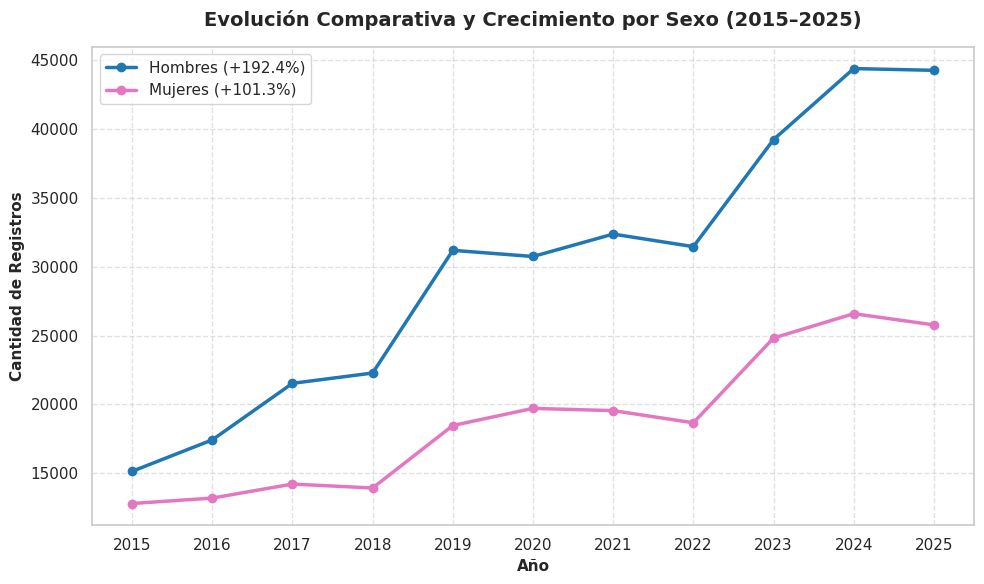

In [10]:
# 1. Obtener valores iniciales (2015) y finales (2025)
val_male_2015 = df_year.loc[df_year['year'] == 2015, 'male'].values[0]
val_male_2025 = df_year.loc[df_year['year'] == 2025, 'male'].values[0]

val_female_2015 = df_year.loc[df_year['year'] == 2015, 'female'].values[0]
val_female_2025 = df_year.loc[df_year['year'] == 2025, 'female'].values[0]

# 2. Calcular incremento porcentual acumulado (2015-2025)
pct_male = ((val_male_2025 - val_male_2015) / val_male_2015) * 100
pct_female = ((val_female_2025 - val_female_2015) / val_female_2015) * 100

print(f'Crecimiento acumulado Hombres (2015-2025): {pct_male:.2f}%')
print(f'Crecimiento acumulado Mujeres (2015-2025): {pct_female:.2f}%')


sns.set_theme(style='whitegrid')

plt.figure(figsize=(10, 6))

# Gráfica para Hombres
plt.plot(
    df_year['year'],
    df_year['male'],
    marker='o',
    linewidth=2.5,
    color='#1f77b4',
    label=f'Hombres (+{pct_male:.1f}%)',
)

# Gráfica para Mujeres
plt.plot(
    df_year['year'],
    df_year['female'],
    marker='o',
    linewidth=2.5,
    color='#e377c2',
    label=f'Mujeres (+{pct_female:.1f}%)',
)

plt.title(
    'Evolución Comparativa y Crecimiento por Sexo (2015–2025)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Año', fontsize=11, fontweight='bold')
plt.ylabel('Cantidad de Registros', fontsize=11, fontweight='bold')
plt.xticks(df_year['year'].unique())
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

Al analizar la interacción bivariada entre el sexo de las personas registradas y el año de reporte (2015–2025), se observa una clara disparidad en el crecimiento relativo. La serie temporal revela que los reportes de hombres crecieron a una tasa del +192.4%, comparada con el +101.3% observado en mujeres. Esta diferencia provocó un ensanchamiento continuo de la brecha de género en términos absolutos a lo largo de la década, situando el volumen de casos masculinos cerca del doble que el femenino hacia el final del periodo analizado.

Cuarta Pregunta.

Para responder a la pregunta ¿Cómo ha evolucionado el número de casos a través de los años? Utilizaremos Barras agrupadas y lo revisaremos a traves de los años para ver la diferencia por año en desapariciones totales.

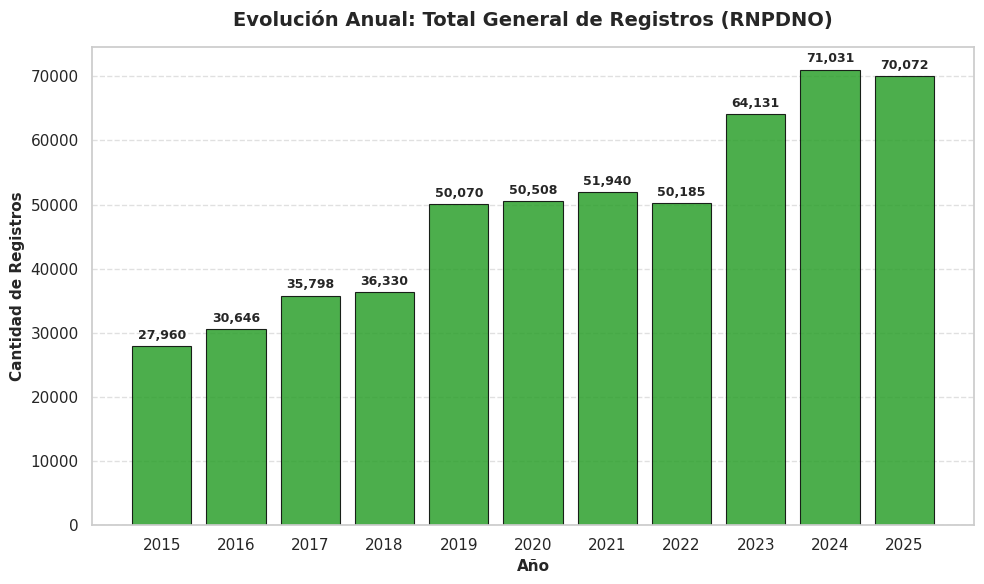

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

# Gráfico de barras para la columna 'total'
bars = ax.bar(
    df_year['year'],
    df_year['total'],
    color='#2ca02c',
    edgecolor='black',
    linewidth=0.8,
    alpha=0.85,
)

# Títulos y etiquetas
ax.set_title(
    'Evolución Anual: Total General de Registros (RNPDNO)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
ax.set_xlabel('Año', fontsize=11, fontweight='bold')
ax.set_ylabel('Cantidad de Registros', fontsize=11, fontweight='bold')

# Asegurar que todos los años se muestren en el eje X como enteros
ax.set_xticks(df_year['year'].unique())

# Agregar etiquetas de valor sobre cada barra
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9, fontweight='bold')

# Ajustar cuadrícula vertical/horizontal
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
ax.grid(False, axis='x')

plt.tight_layout()
plt.show()

Analisis.

1. **Tendencia General de Crecimiento**



   *  **Tendencia alcista sostenida:** La serie muestra un crecimiento significativo al comparar el inicio y el final del periodo. Los registros pasaron de 27,960 en 2015 a 70,072 en 2025, lo que representa un incremento total acumulado del +150.6%.  


    *   **Pico máximo histórico:** El año con mayor volumen de registros en la serie es 2024 (71,031 casos), seguido muy de cerca por 2025 (70,072 casos).


2. **Etapas o Comportamientos por Periodo (Quiebres Visibles)**

    Se aprecian tres etapas claramente diferenciadas en la evolución de la serie:



*   **Periodo de crecimiento gradual (2015–2018):**

  El número de casos crece de manera sostenida pero moderada, pasando de ~28k en 2015 a ~36.3k en 2018.   
*   **Primer salto escalonado y meseta (2019–2022):**

    En 2019 ocurre un salto brusco en los registros (+37.8% respecto a 2018), superando por primera vez los 50,000 registros anuales.   

    Entre 2019 y 2022 la serie entra en una fase de estabilización/meseta, oscilando en un rango estrecho entre 50,070 y 51,940 registros anuales.

* **Segundo salto significativo (2023–2025):**

    A partir de 2023 se observa un nuevo aceleramiento (+27.8% respecto a 2022), alcanzando cifras superiores a los 64k registros en 2023 y rebasando los 70k en 2024 y 2025.   

3. **Consideraciones y Preguntas Metodológicas.**

    **Análisis de la Ley de 2017:**
    
    Aunque la Ley General en Materia de Desaparición se promulgó a finales de 2017, la gráfica muestra que el salto drástico en los datos del registro no ocurre inmediatamente en 2018 (36,330 casos), sino en 2019 (50,070 casos). Esto puede sugerir un tiempo de rezago (lag) institucional en la implementación de las bases de datos unificadas y la digitalización de expedientes.  

QUINTA PREGUNTA:
¿Qué entidades concentran más casos y cómo se distribuyen según condición?

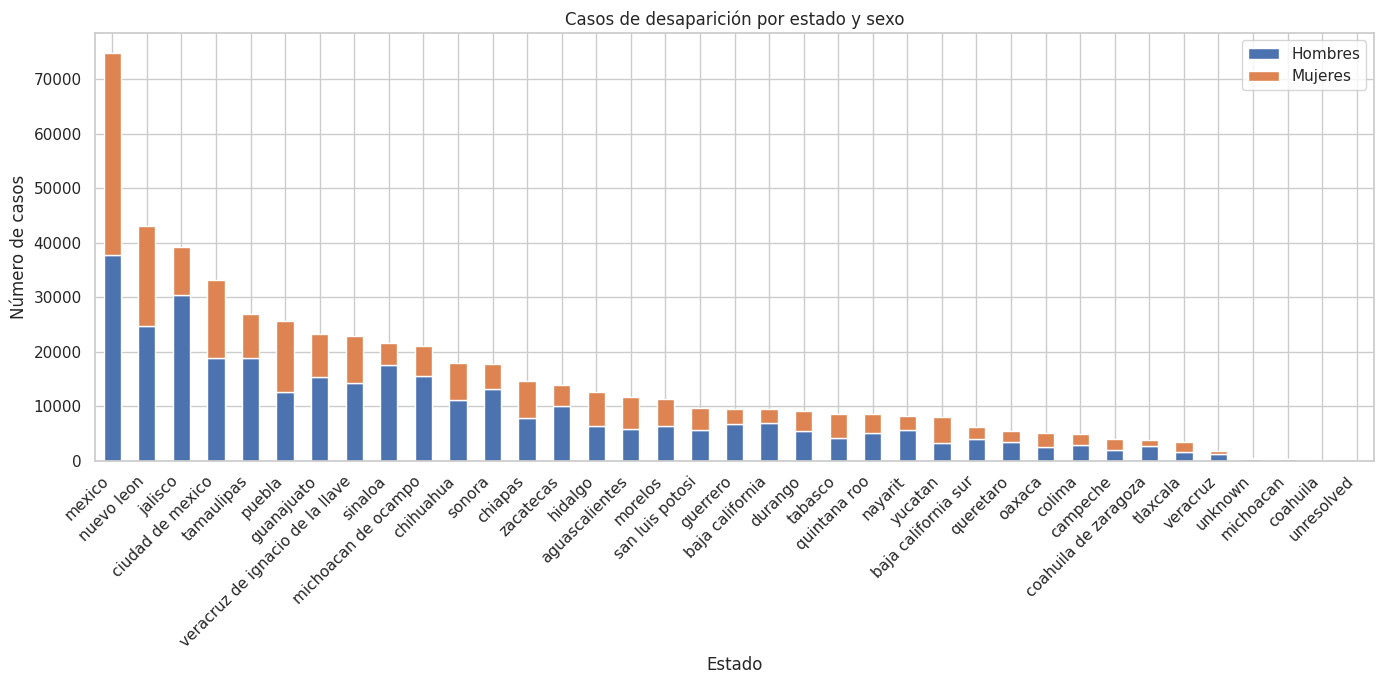

In [12]:
# PRimero comenzamos por grupar los Estados
df_estado = df.groupby(
    ['cve_estado', 'state']
)[['male', 'female']].sum().reset_index()

# Ordenar el total de casos
df_estado['total'] = df_estado['male'] + df_estado['female']
df_estado = df_estado.sort_values('total', ascending=False)

# Gráfico de total de casos
ax = df_estado.set_index('state')[['male', 'female']].plot(
    kind='bar',
    figsize=(14, 7),
    stacked=True
)

plt.title('Casos de desaparición por estado y sexo')
plt.xlabel('Estado')
plt.ylabel('Número de casos')
plt.xticks(rotation=45, ha='right')
plt.legend(['Hombres', 'Mujeres'])
plt.tight_layout()
plt.show()


Así mismo, podemos complementar y realizar un análisis con los municipios.

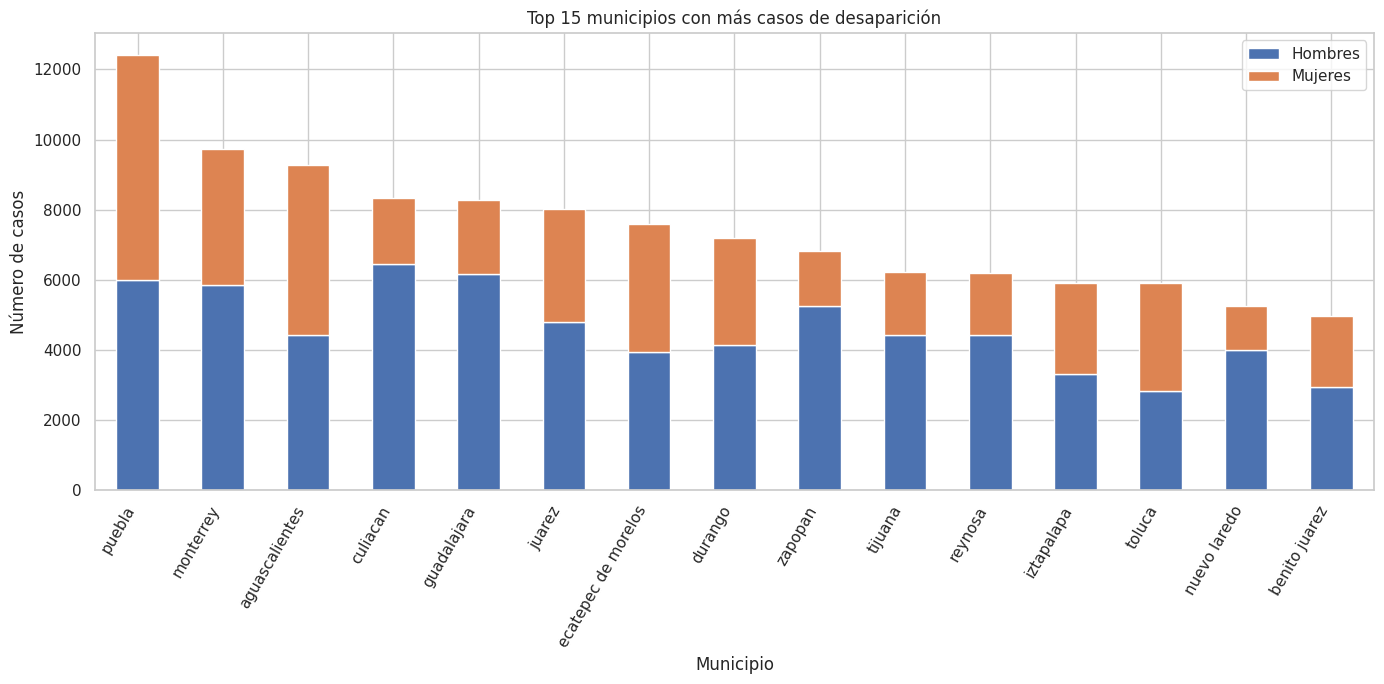

In [13]:
df_municipio = df.groupby(
    ['cve_estado', 'state', 'cve_mun', 'municipality']
)[['male', 'female']].sum().reset_index()

# Total hombres + mujeres
df_municipio['total'] = (
    df_municipio['male'] + df_municipio['female']
)

# Top 15 municipios
top_municipios = df_municipio.sort_values(
    'total',
    ascending=False
).head(15)

# Gráfico
ax = top_municipios.set_index('municipality')[['male', 'female']].plot(
    kind='bar',
    figsize=(14, 7),
    stacked=True
)

plt.title('Top 15 municipios con más casos de desaparición')
plt.xlabel('Municipio')
plt.ylabel('Número de casos')
plt.xticks(rotation=60, ha='right')
plt.legend(['Hombres', 'Mujeres'])
plt.tight_layout()
plt.show()


Análisis:
A partir del análisis descriptivo de los registros de desapariciones, se puede concluir que el fenómeno presenta diferencias importantes tanto entre entidades federativas como entre hombres y mujeres. La comparación mediante gráficos de barras permite observar que el número de casos no se distribuye de manera uniforme entre los estados, existiendo entidades con una mayor concentración de registros.
Es importante señalar que estos resultados son descriptivos y no implican necesariamente una relación causal entre el sexo, la condición y la entidad. Sin embargo, permiten identificar patrones y diferencias territoriales que pueden ser útiles para realizar análisis posteriores más profundos.

CONCLUSIÓN DE LA PREGUNTA 5:


*   México concentra la mayor cantidad de casos, con una diferencia considerable respecto al resto de los estados.
*   En prácticamente todos los estados, los hombres presentan más casos que las mujeres, aunque la diferencia varía según el estado.

*   Después de México, destacan **Nuevo León, Jalisco, Ciudad de México y Tamaulipas** por el número total de casos.
*   Existe una gran desigualdad entre estados: algunos concentran decenas de miles de casos, mientras que otros presentan cantidades mucho menores.
*   En estados como **Puebla, Guanajuato y Veracruz,** también se observa una cantidad importante de casos.
*   El gráfico sugiere que el fenómeno de las desapariciones no está distribuido uniformemente en el país y que hay estados donde el problema es considerablemente mayor.





SEXTA PREGUNTA: ¿Cómo se relacionan sexo y condición, considerando las entidades?

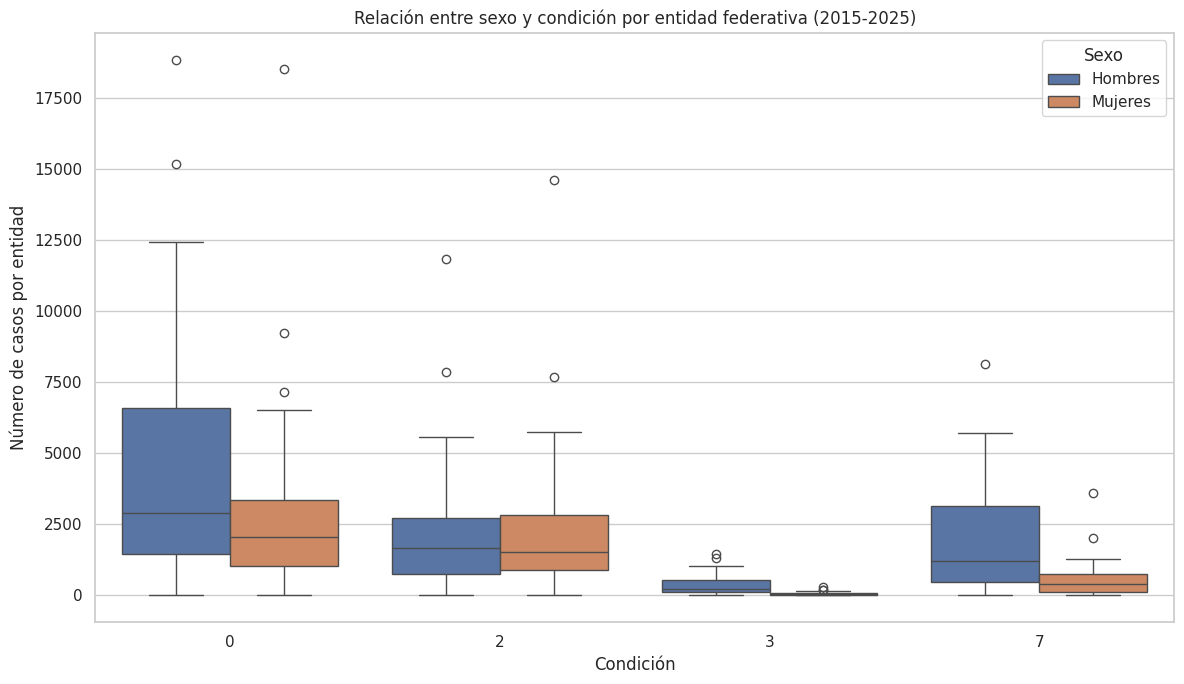

In [14]:
# Agrupa por entidad y condición
df_box = df.groupby(
    ['state', 'status_id']
)[['male', 'female']].sum().reset_index()

# Converte male/female a una sola variable "sexo"
df_box = df_box.melt(
    id_vars=['state', 'status_id'],
    value_vars=['male', 'female'],
    var_name='sexo',
    value_name='casos'
)

# Cambiamos los nombres a "Hombres y mujeres" esto fue opcinonal
df_box['sexo'] = df_box['sexo'].map({
    'male': 'Hombres',
    'female': 'Mujeres'
})

# Boxplot
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_box,
    x='status_id',
    y='casos',
    hue='sexo'
)

plt.title('Relación entre sexo y condición por entidad federativa (2015-2025)')
plt.xlabel('Condición')
plt.ylabel('Número de casos por entidad')
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()


Interpretación de los resutados:

La línea dentro de la caja representa la mediana de casos entre entidades.

*   La caja representa el rango intercuartílico (50% central de las entidades).
*   Los bigotes muestran la dispersión de los datos.
*   Los puntos alejados son entidades con valores atípicos.
*   Se puede observar que condición tiene sistemáticamente más casos de hombres o mujeres.


Análisi: El análisis mediante boxplot muestra que la relación entre sexo y condición varía entre las entidades. En términos generales, las diferencias en la cantidad de casos de hombres y mujeres pueden cambiar dependiendo de la condición registrada, mientras que algunas entidades presentan valores considerablemente superiores al resto, lo que se refleja como una mayor dispersión y posibles valores atípicos.

CONCLUSIÓN DE LA PREGUNTA 6:

*   0 (Total): es la categoría con mayor número de casos. Los hombres presentan una mediana superior a la de las mujeres y también una mayor dispersión. Esto indica que, en general, hay más hombres registrados como desaparecidos/no localizados.
*   2 (Con vida): hombres y mujeres presentan cantidades bastante similares, aunque los hombres tienen una mediana ligeramente mayor. También se observan valores extremos importantes, especialmente en hombres.
*   3 (Sin vida): es la categoría con menos casos. Tanto hombres como mujeres presentan valores relativamente bajos, aunque nuevamente los hombres muestran una cantidad ligeramente mayor y algunos valores atípicos.

*   7 (No localizado): existe una diferencia más marcada: los hombres tienen muchos más casos que las mujeres. La distribución masculina es más amplia y presenta valores extremos elevados.

El sexo masculino concentra la mayor cantidad de casos en todas las condiciones analizadas. La diferencia es especialmente evidente en la categoría “No localizado (7)” y en el total de casos. En cambio, en “Con vida (2)” las cantidades de hombres y mujeres son más similares. La categoría “Sin vida (3)” presenta los valores más bajos para ambos sexos.